# Structural relaxation of twisted bilayer graphene
Rigidly twisting two graphene layers is only an approximation. Below a few degrees of twist
the real lattice relaxes, so that the energetically costly AA-stacked regions shrink and
triangular AB/BA (Bernal) domains grow around them, separated by domain walls.
`GrapheneGeometry(g).relax()` reproduces this by minimizing, over an in-plane displacement
of every atom, the sum of two energies: the interlayer generalized stacking fault energy
(GSFE), a periodic function of the local registry of the two layers with its maximum at AA
stacking and two degenerate minima at AB and BA, and the intralayer elastic energy, with the
parameters of [arXiv:1805.06972](https://arxiv.org/abs/1805.06972). The relaxation is
in-plane only, and `GrapheneHamiltonian(g)` builds the tight-binding Hamiltonian from the
relaxed positions, so that they feed into the electronic structure.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from pyqula import specialgeometry
from pyqula.graphenetk.geometry import GrapheneGeometry

### Relaxing a bilayer twisted by about two degrees
`.relax()` returns a new geometry and leaves the rigid one untouched, so the two can be
compared. The map below is the in-plane displacement of each atom, with arrows showing its
direction, repeated over a few moire cells. The atoms rotate around the AA regions, and the
two layers do it in opposite senses, which locally increases the twist at AA and reduces it
in the AB/BA domains between them. Positions are in units of the carbon-carbon distance.

Theta 2.1339296665972505


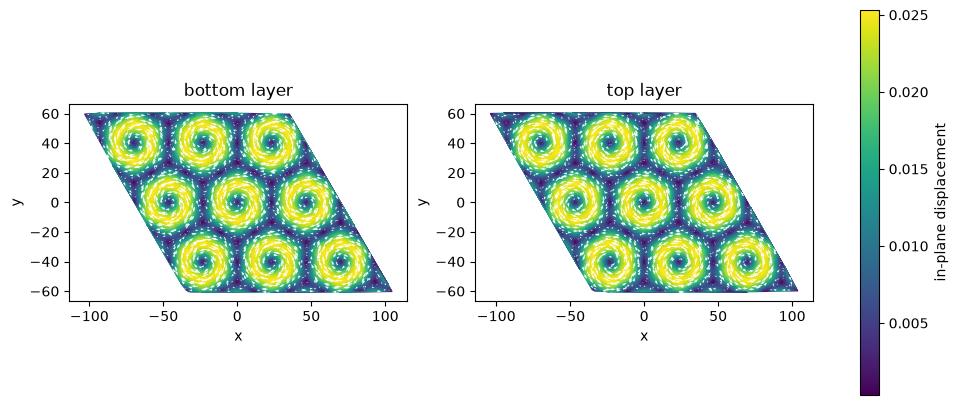

In [2]:
g0 = specialgeometry.twisted_bilayer(m0=15) # rigid bilayer, about 2 degrees of twist
g = GrapheneGeometry(g0).relax() # relaxed bilayer

r0 = np.array(g0.r) ; r = np.array(g.r) # rigid and relaxed positions
u = r - r0 # in-plane displacement of every atom
bottom = r0[:,2]<np.mean(r0[:,2]) # atoms of the bottom layer
a1 = np.array(g0.a1) ; a2 = np.array(g0.a2) # moire lattice vectors

def tile(x,y,f,n=1): # repeat a map over the neighboring moire cells
    xs,ys,fs = [],[],[]
    for i in range(-n,n+1):
        for j in range(-n,n+1):
            s = i*a1 + j*a2
            xs.append(x+s[0]) ; ys.append(y+s[1]) ; fs.append(f)
    return np.concatenate(xs),np.concatenate(ys),np.concatenate(fs)

fig,axs = plt.subplots(1,2,figsize=(12,5))
for (ax,layer,title) in zip(axs,[bottom,~bottom],["bottom layer","top layer"]):
    x,y,ux = tile(r0[layer,0],r0[layer,1],u[layer,0])
    x,y,uy = tile(r0[layer,0],r0[layer,1],u[layer,1])
    im = ax.tripcolor(x,y,np.sqrt(ux**2+uy**2),cmap="viridis",shading="gouraud")
    sel = np.arange(len(x))[::9] # a subset of the atoms for the arrows
    ax.quiver(x[sel],y[sel],ux[sel],uy[sel],color="white")
    ax.set_aspect("equal") ; ax.set_title(title)
    ax.set_xlabel("x") ; ax.set_ylabel("y")
plt.colorbar(im,ax=axs,label="in-plane displacement")
plt.show()

### Local stacking: the AA regions shrink
To see the domains, we measure the local stacking at each atom of the bottom layer as the
in-plane distance to the closest atom of the same sublattice in the top layer. It is zero
where the stacking is AA, where every atom sits on top of an atom of the same sublattice, and
one carbon-carbon distance in the AB and BA domains. The map on the left is the relaxed
stacking around one AA region, with the contours where it equals 0.3 and 0.6 for the rigid
(dashed) and relaxed (solid) bilayers, and the map on the right is the change produced by
the relaxation over a few moire cells: the AA regions contract, and the region around them
moves toward Bernal stacking. The effect grows as the twist angle decreases.

fraction of the cell with AA-like stacking (d<0.3):
  rigid   0.106
  relaxed 0.084


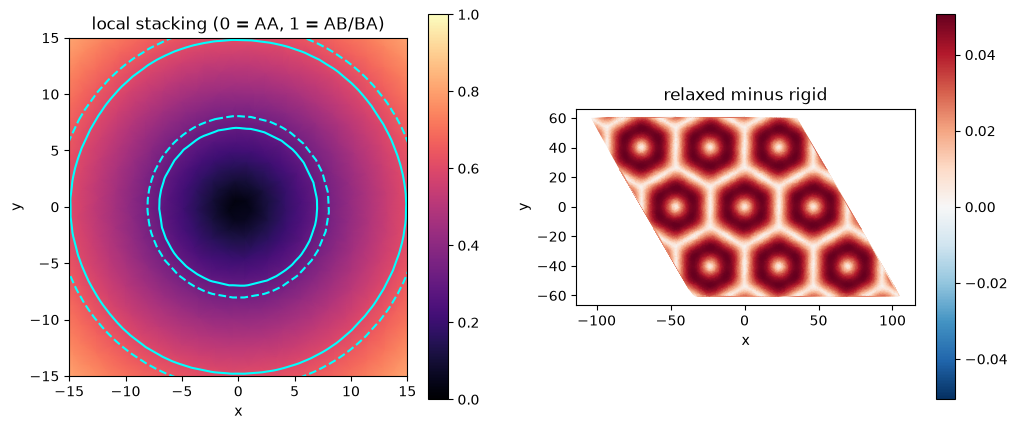

In [3]:
def local_stacking(gi): # distance to the closest same-sublattice atom of the other layer
    ri = np.array(gi.r) ; s = np.array(gi.sublattice)
    bot = ri[:,2]<np.mean(ri[:,2]) ; top = ~bot
    d = np.zeros(len(ri))
    for sub in np.unique(s):
        rt = ri[top & (s==sub),:2] # top layer, this sublattice
        images = np.concatenate([rt+i*a1[:2]+j*a2[:2] for i in (-1,0,1) for j in (-1,0,1)])
        sel = bot & (s==sub)
        d[sel] = cKDTree(images).query(ri[sel,:2])[0]
    return d[bot]

d0 = local_stacking(g0) # rigid bilayer
d1 = local_stacking(g) # relaxed bilayer
print("fraction of the cell with AA-like stacking (d<0.3):")
print("  rigid  ",np.round(np.mean(d0<0.3),3))
print("  relaxed",np.round(np.mean(d1<0.3),3))

x,y,f1 = tile(r0[bottom,0],r0[bottom,1],d1)
x,y,f0 = tile(r0[bottom,0],r0[bottom,1],d0)
fig,axs = plt.subplots(1,2,figsize=(12,5))
im0 = axs[0].tripcolor(x,y,f1,cmap="magma",vmin=0.,vmax=1.,shading="gouraud")
axs[0].tricontour(x,y,f0,levels=[0.3,0.6],colors="cyan",linestyles="dashed")
axs[0].tricontour(x,y,f1,levels=[0.3,0.6],colors="cyan")
axs[0].set_xlim([-15.,15.]) ; axs[0].set_ylim([-15.,15.]) # one AA region
axs[0].set_title("local stacking (0 = AA, 1 = AB/BA)")
plt.colorbar(im0,ax=axs[0])
dm = np.max(np.abs(f1-f0))
im1 = axs[1].tripcolor(x,y,f1-f0,cmap="RdBu_r",vmin=-dm,vmax=dm,shading="gouraud")
axs[1].set_title("relaxed minus rigid")
plt.colorbar(im1,ax=axs[1])
for ax in axs:
    ax.set_aspect("equal") ; ax.set_xlabel("x") ; ax.set_ylabel("y")
plt.show()